<a href="https://colab.research.google.com/github/rfaoktvian/Dicoding_FinalProject/blob/main/FractureNet_High_Sensitivity_X_Ray_Image_Classification_for_Orthopedic_Diagnostics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BUSINESS UNDERSTANDING


### ABOUT PROJECT

Diagnosis patah tulang (bone fracture) melalui citra X-ray adalah salah satu tugas paling umum namun krusial dalam radiologi. Di unit gawat darurat (UGD) yang sibuk, beban kerja radiolog yang tinggi dapat menyebabkan kelelahan, yang berisiko pada missed diagnosis—terutama pada kasus retakan rambut (hairline fractures) yang sangat tipis dan samar.

Proyek ini bertujuan untuk membangun sistem pendukung keputusan klinis (Clinical Decision Support System) berbasis Deep Learning yang mampu melakukan Skrining Otomatis: Mendeteksi keberadaan patah tulang pada berbagai wilayah tubuh (Multi-Region) secara instan.

Dataset:
Dataset yang digunakan adalah Fracture Multi-Region X-ray Steps yang mencakup berbagai anatomi tubuh (seperti tangan, kaki, panggul, dll). Berikut sumber dari dataset yang digunakan:
https://www.kaggle.com/datasets/bmadushanirodrigo/fracture-multi-region-x-ray-data .


### IMPORT LIBRARY

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import tensorflow as tf
from tensorflow.keras import layers,models,callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report
import os

### LOAD DATASET

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

base_dir = '/content/drive/MyDrive/Dicoding/FinalProject/ProyeksiGambar/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification'
TRAIN_PATH = os.path.join(base_dir,'train')
VAL_PATH = os.path.join(base_dir,'val')
TEST_PATH = os.path.join(base_dir,'test')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## EXPLORATORY DATA ANALYSIS

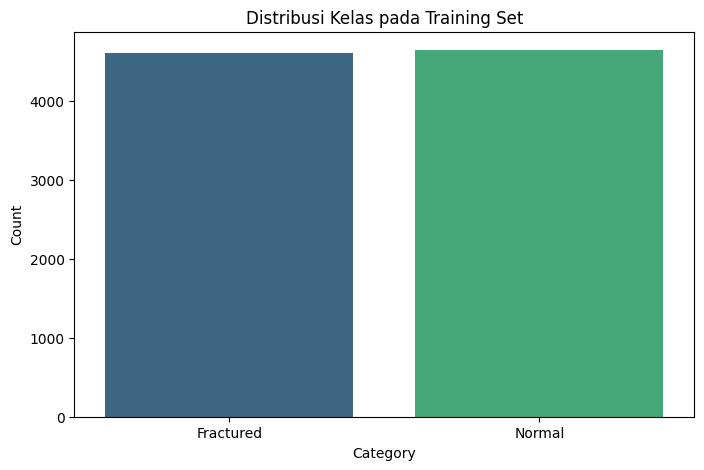

Total Fractured: 4606
Total Normal: 4640


In [ ]:
train_fractured = len(os.listdir(os.path.join(TRAIN_PATH, 'fractured')))
train_normal = len(os.listdir(os.path.join(TRAIN_PATH, 'not fractured')))

data = {'Category': ['Fractured', 'Normal'], 'Count': [train_fractured, train_normal]}
df = pd.DataFrame(data)

plt.figure(figsize=(8, 5))
sns.barplot(x='Category', y='Count', hue='Category', data=df, palette='viridis',legend=False)
plt.title('Distribusi Kelas pada Training Set')
plt.show()

print(f"Total Fractured: {train_fractured}")
print(f"Total Normal: {train_normal}")

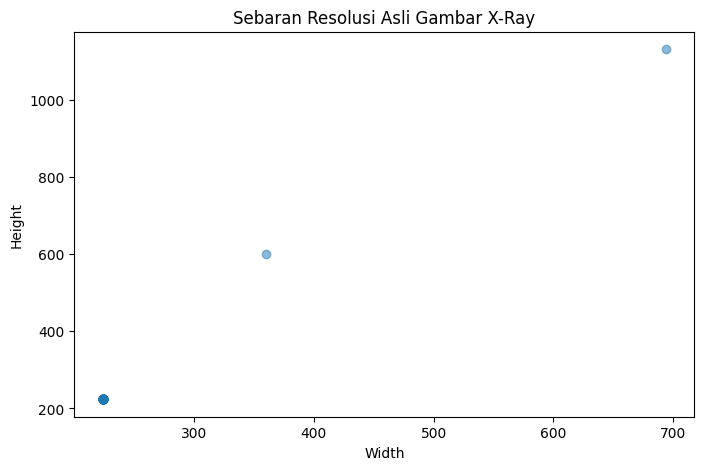

In [ ]:
from PIL import Image,ImageFile

sample_dir = os.path.join(TRAIN_PATH, 'fractured')
sample_files = os.listdir(sample_dir)[:50]

widths = []
heights = []

for file in sample_files:
    img = Image.open(os.path.join(sample_dir, file))
    widths.append(img.size[0])
    heights.append(img.size[1])

plt.figure(figsize=(8, 5))
plt.scatter(widths, heights, alpha=0.5)
plt.xlabel('Width')
plt.ylabel('Height')
plt.title('Sebaran Resolusi Asli Gambar X-Ray')
plt.show()

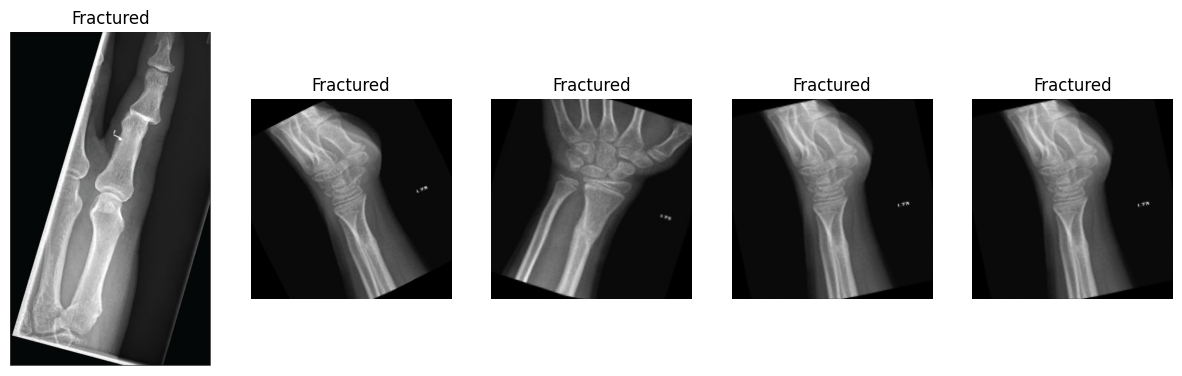

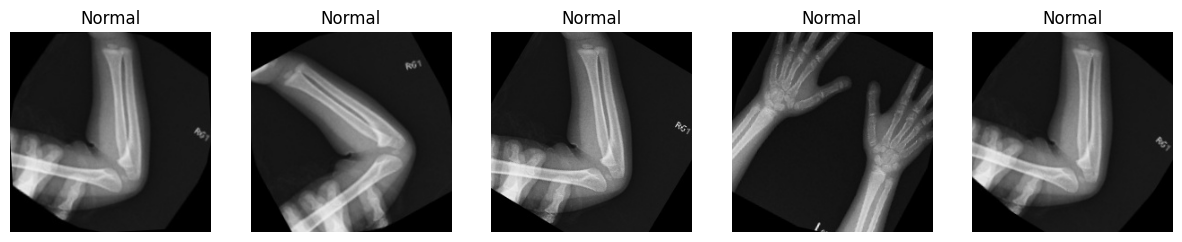

In [ ]:
ImageFile.LOAD_TRUNCATED_IMAGES = True
def plot_raw_samples(path, title):
    files = os.listdir(path)[:5]
    plt.figure(figsize=(15, 5))
    for i, file in enumerate(files):
        img = Image.open(os.path.join(path, file))
        plt.subplot(1, 5, i+1)
        plt.imshow(img, cmap='gray')
        plt.title(title)
        plt.axis('off')
    plt.show()
plot_raw_samples(os.path.join(TRAIN_PATH, 'fractured'), "Fractured")
plot_raw_samples(os.path.join(TRAIN_PATH, 'not fractured'), "Normal")

## DATA PREPROCESSING & AUGMENTATION DATA

In [ ]:
def apply_clahe(img):
    img_uint8 = img.astype('uint8')
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    final_img = clahe.apply(img_uint8)
    return final_img.reshape(224, 224, 1).astype('float32')

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    horizontal_flip=True,
    preprocessing_function=apply_clahe
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    color_mode='grayscale'
)

Found 9246 images belonging to 2 classes.


In [ ]:
val_test_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_generator = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='grayscale'
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='grayscale',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='grayscale',
    shuffle=False
)

Found 9246 images belonging to 2 classes.
Found 829 images belonging to 2 classes.
Found 506 images belonging to 2 classes.


In [ ]:
def build_model():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 1)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

model = build_model()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │    47,776,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,795,457 (182.33 MB)

 Trainable params: 47,795,265 (182.32 MB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall')]
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('fracture_net_best.h5', save_best_only=True, monitor='val_loss')

callbacks_list = [early_stop, checkpoint]

In [ ]:
EPOCHS = 10
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks_list
)

Epoch 1/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.7627 - loss: 1.2505 - recall: 0.7528

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


289/289 ━━━━━━━━━━━━━━━━━━━━ 1602s 6s/step - accuracy: 0.8210 - loss: 0.7431 - recall: 0.8162 - val_accuracy: 0.5935 - val_loss: 9.1516 - val_recall: 1.0000
Epoch 2/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9141 - loss: 0.2806 - recall: 0.9171

289/289 ━━━━━━━━━━━━━━━━━━━━ 1640s 6s/step - accuracy: 0.9229 - loss: 0.2859 - recall: 0.9248 - val_accuracy: 0.7443 - val_loss: 3.1863 - val_recall: 0.9634
Epoch 3/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9398 - loss: 0.2480 - recall: 0.9364

289/289 ━━━━━━━━━━━━━━━━━━━━ 1589s 5s/step - accuracy: 0.9444 - loss: 0.2294 - recall: 0.9425 - val_accuracy: 0.8661 - val_loss: 1.2614 - val_recall: 0.9207
Epoch 4/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9603 - loss: 0.1513 - recall: 0.9611

289/289 ━━━━━━━━━━━━━━━━━━━━ 1605s 6s/step - accuracy: 0.9625 - loss: 0.1400 - recall: 0.9627 - val_accuracy: 0.9192 - val_loss: 0.6638 - val_recall: 0.9715
Epoch 5/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9691 - loss: 0.1241 - recall: 0.9712

289/289 ━━━━━━━━━━━━━━━━━━━━ 1605s 6s/step - accuracy: 0.9685 - loss: 0.1163 - recall: 0.9716 - val_accuracy: 0.9192 - val_loss: 0.6124 - val_recall: 0.9492
Epoch 6/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 1596s 6s/step - accuracy: 0.9729 - loss: 0.0961 - recall: 0.9711 - val_accuracy: 0.9083 - val_loss: 1.0926 - val_recall: 0.9573
Epoch 7/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 1592s 6s/step - accuracy: 0.9772 - loss: 0.0763 - recall: 0.9772 - val_accuracy: 0.9095 - val_loss: 0.9868 - val_recall: 0.9472
Epoch 8/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 1580s 5s/step - accuracy: 0.9788 - loss: 0.0917 - recall: 0.9804 - val_accuracy: 0.9011 - val_loss: 0.7874 - val_recall: 0.9350
Epoch 9/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9772 - loss: 0.0652 - recall: 0.9750

289/289 ━━━━━━━━━━━━━━━━━━━━ 1625s 6s/step - accuracy: 0.9805 - loss: 0.0626 - recall: 0.9800 - val_accuracy: 0.9530 - val_loss: 0.3432 - val_recall: 0.9837
Epoch 10/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 1614s 6s/step - accuracy: 0.9773 - loss: 0.0893 - recall: 0.9782 - val_accuracy: 0.9361 - val_loss: 0.8315 - val_recall: 0.9837


In [1]:
test_loss, test_accuracy, test_recall = model.evaluate(test_generator)
print(f"\n{'='*50}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"{'='*50}\n")

NameError: name 'model' is not defined

In [ ]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Val Loss', marker='s')
plt.title('Model Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)